# Distribution Analysis

> Understanding the structure of the Diabetes 130-US dataset before running federated experiments.
> This notebook has two goals:
> 1. **Global distributions** — class-conditional feature statistics that inform what the FedGen generator *should* learn to approximate.
> 2. **Dirichlet heterogeneity** — how client distributions diverge from the global as α decreases, providing an empirical basis for the accuracy-vs-communication-cost Pareto analysis.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, entropy, ks_2samp
import warnings
import sys
import os

warnings.filterwarnings('ignore')
sys.path.append('..')

from UC1Utils import (
    load_data, drop_columns, remove_deceased, create_target,
    encode_features, _impute_and_group_specialty,
    prepare_data, ensure_data, CSV_MAIN
)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':       130,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
PALETTE = {'Not readmitted (0)': '#4878CF', 'Readmitted <30d (1)': '#E24A33'}
ALPHA_SWEEP = [0.1, 0.5, 1.0, 5.0]
N_CLIENTS   = 5
SEED        = 42

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

We work at two levels:
- **Raw DataFrame** (pre-OHE) — for clinical feature distributions.
- **Encoded matrix** (post-OHE) — for federated partitioning and Wasserstein analysis.

In [2]:
ensure_data()

# ── Load and preprocess up to (but not including) OHE ─────────────────────────
# We keep a pre-OHE DataFrame for clinical interpretation.
df_raw = load_data(CSV_MAIN)
df_raw = drop_columns(df_raw)
df_raw = remove_deceased(df_raw)
df_raw = create_target(df_raw)
df_raw['race'] = df_raw['race'].fillna('Unknown')
df_raw = _impute_and_group_specialty(df_raw)
df_raw['A1Cresult']     = df_raw['A1Cresult'].fillna('none')
df_raw['max_glu_serum'] = df_raw['max_glu_serum'].fillna('none')
df_raw.dropna(inplace=True)

# Apply encode_features which adds engineered columns but also OHEs —
# we'll rebuild a pre-OHE version for visualization.
# The approach: apply everything EXCEPT get_dummies by reconstructing manually.
from UC1Utils import AGE_MAP, ADMISSION_TYPE_MAP, ADMISSION_SOURCE_MAP, MED_MAP, MED_COLS, LOW_INFO_MEDS
from UC1Utils import group_discharge, group_icd9

df = df_raw.copy()
df['age'] = df['age'].map(AGE_MAP)
df['service_utilization'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']
df['admission_type_id']        = df['admission_type_id'].map(ADMISSION_TYPE_MAP).fillna('unknown')
df['admission_source_id']      = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('unknown')
df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(group_discharge)
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(group_icd9)
for col in MED_COLS:
    if col in df.columns:
        df[col] = df[col].map(MED_MAP)
active_meds = [c for c in MED_COLS if c in df.columns]
df['medication_count'] = df[active_meds].sum(axis=1)
df.drop(columns=[c for c in LOW_INFO_MEDS if c in df.columns], inplace=True)
df['HbA1c_diabetes_interaction'] = (
    (df['A1Cresult'] != 'none') & (df['diag_1'] == 'diabetes')
).astype(int)
df['change']      = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# ── Fully encoded matrix ───────────────────────────────────────────────────────
X, y, groups, feature_names = prepare_data(CSV_MAIN, verbose=True)

df_enc = pd.DataFrame(X, columns=feature_names)
df_enc['readmitted_binary'] = y

print(f'\nPre-OHE DataFrame: {df.shape}')
print(f'Encoded matrix:    {df_enc.shape}')

✓ CSV files already present, skipping extraction.
dropna removed 1518 rows (1.53%) — likely from unmapped admission_type/source IDs
Dataset shape after cleaning: (97825, 101)
Class distribution:
readmitted_binary
0    86618
1    11207
Name: count, dtype: int64
Imbalance ratio: 7.73:1  (positive rate: 11.46%)

Pre-OHE DataFrame: (97825, 40)
Encoded matrix:    (97825, 100)


## 2. Global Class Distribution

The 7.73:1 imbalance is the single most structurally important property of this dataset.
It directly affects what the generator must learn: class 1 is rare, so its latent
representations are also sparsely sampled during generator training.

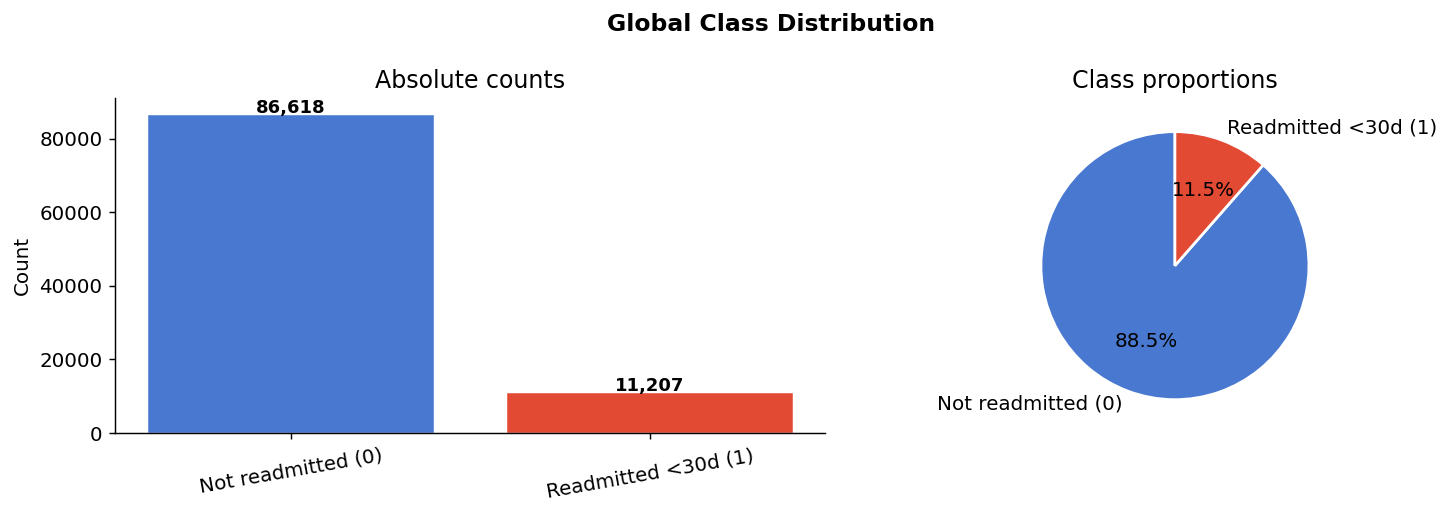

Imbalance ratio: 7.73:1  |  Positive rate: 11.46%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Global Class Distribution', fontweight='bold', fontsize=13)

counts = pd.Series(y).value_counts().sort_index()
labels = ['Not readmitted (0)', 'Readmitted <30d (1)']
colors = list(PALETTE.values())

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Absolute counts')
axes[0].tick_params(axis='x', rotation=10)

axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1  |  Positive rate: {counts[1]/len(y)*100:.2f}%')

## 3. Class-Conditional Distributions: Continuous Features

These are the features whose class-conditional distributions the generator is implicitly
trying to capture in latent space. Large separations between the two class distributions
indicate high discriminative power — and also indicate where a biased local dataset
will produce the worst model drift.

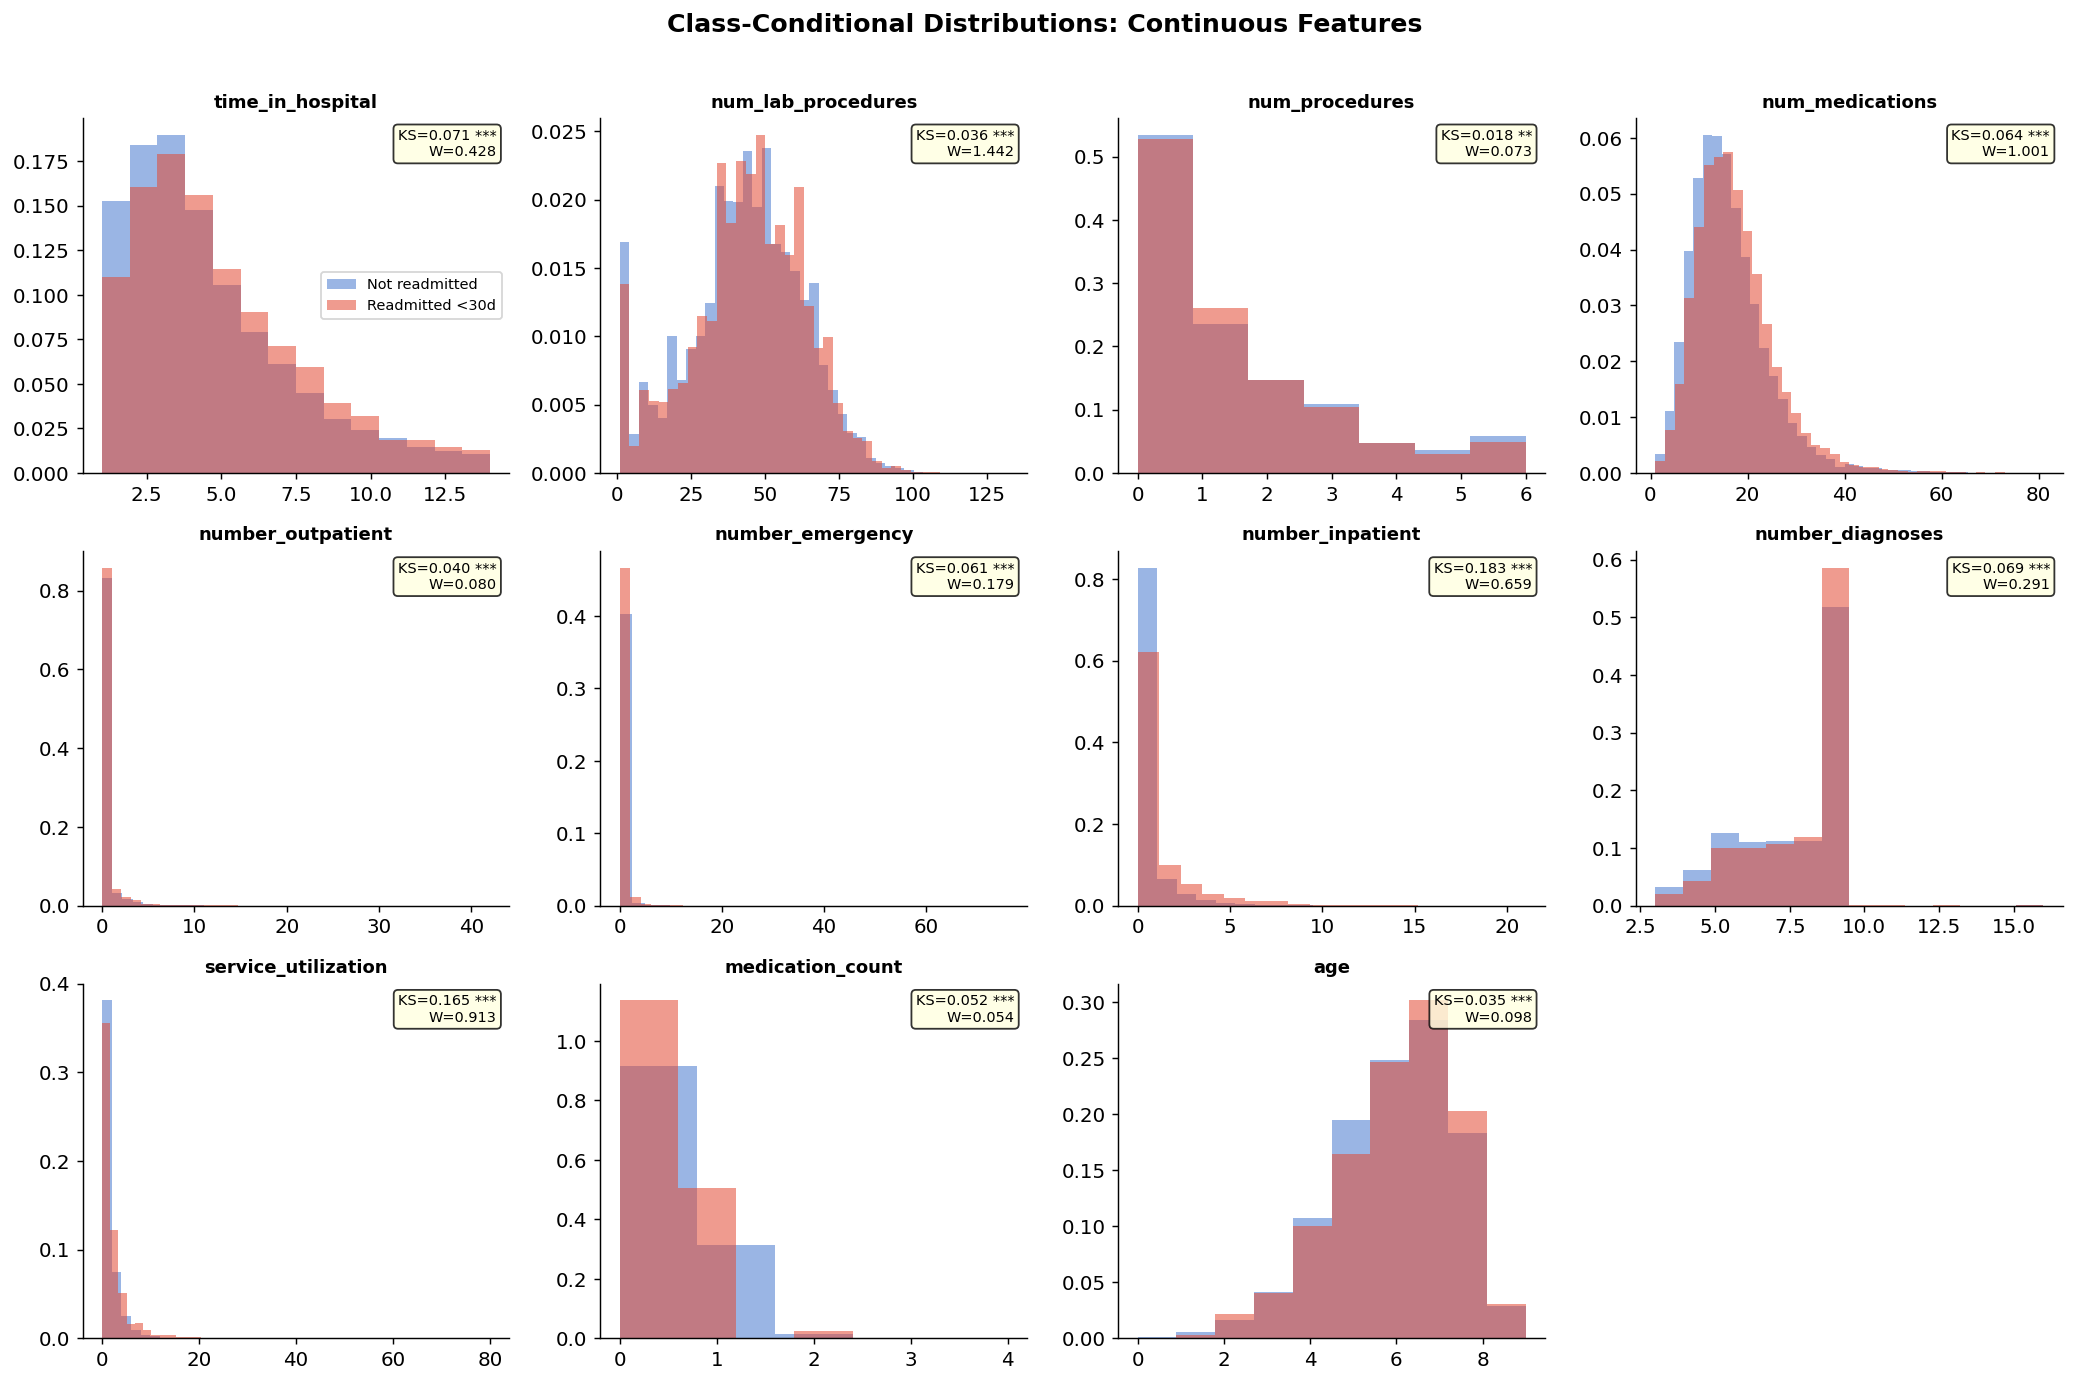


Kolmogorov-Smirnov test: class-conditional separation
(Higher KS = more discriminative, more sensitive to distribution shift)

            Feature  KS statistic       p-value Significant
   number_inpatient      0.183136 9.717136e-292         ***
service_utilization      0.164981 1.659051e-236         ***
   time_in_hospital      0.071369  2.139068e-44         ***
   number_diagnoses      0.068886  2.184919e-41         ***
    num_medications      0.064051  7.788025e-36         ***
   number_emergency      0.061086  1.245366e-32         ***
   medication_count      0.052175  6.441043e-24         ***
  number_outpatient      0.040167  2.393455e-14         ***
 num_lab_procedures      0.035678  2.073279e-11         ***
                age      0.034581  9.583534e-11         ***
     num_procedures      0.017578  4.290620e-03            


In [4]:
CONTINUOUS_FEATURES = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'service_utilization', 'medication_count', 'age'
]

n_cols = 4
n_rows = int(np.ceil(len(CONTINUOUS_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Class-Conditional Distributions: Continuous Features', fontweight='bold', fontsize=14, y=1.01)
axes = axes.flatten()

df0 = df[df['readmitted_binary'] == 0]
df1 = df[df['readmitted_binary'] == 1]

ks_results = {}

for i, feat in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    v0 = df0[feat].dropna()
    v1 = df1[feat].dropna()

    ks_stat, ks_p = ks_2samp(v0, v1)
    ks_results[feat] = (ks_stat, ks_p)
    wass = wasserstein_distance(v0, v1)

    # KDE plots
    bins = min(40, int(v0.nunique()))
    ax.hist(v0, bins=bins, alpha=0.55, color=list(PALETTE.values())[0],
            density=True, label='Not readmitted')
    ax.hist(v1, bins=bins, alpha=0.55, color=list(PALETTE.values())[1],
            density=True, label='Readmitted <30d')

    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    sign = '***' if ks_p < 0.001 else ('**' if ks_p < 0.01 else ('*' if ks_p < 0.05 else 'ns'))
    ax.annotate(f'KS={ks_stat:.3f} {sign}\nW={wass:.3f}',
                xy=(0.97, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('figures/02_class_conditional_continuous.png', bbox_inches='tight')
plt.show()

# Summary table sorted by KS statistic (discriminative power)
ks_df = pd.DataFrame([
    {'Feature': k, 'KS statistic': v[0], 'p-value': v[1],
     'Significant': '***' if v[1] < 0.001 else ''}
    for k, v in ks_results.items()
]).sort_values('KS statistic', ascending=False).reset_index(drop=True)

print('\nKolmogorov-Smirnov test: class-conditional separation')
print('(Higher KS = more discriminative, more sensitive to distribution shift)\n')
print(ks_df.to_string(index=False))

## 4. Class-Conditional Distributions: Key Categorical Features

Categorical features after grouping. The proportions per class matter for the generator
because the label prior $\hat{p}(y)$ is used to sample labels during generator training.

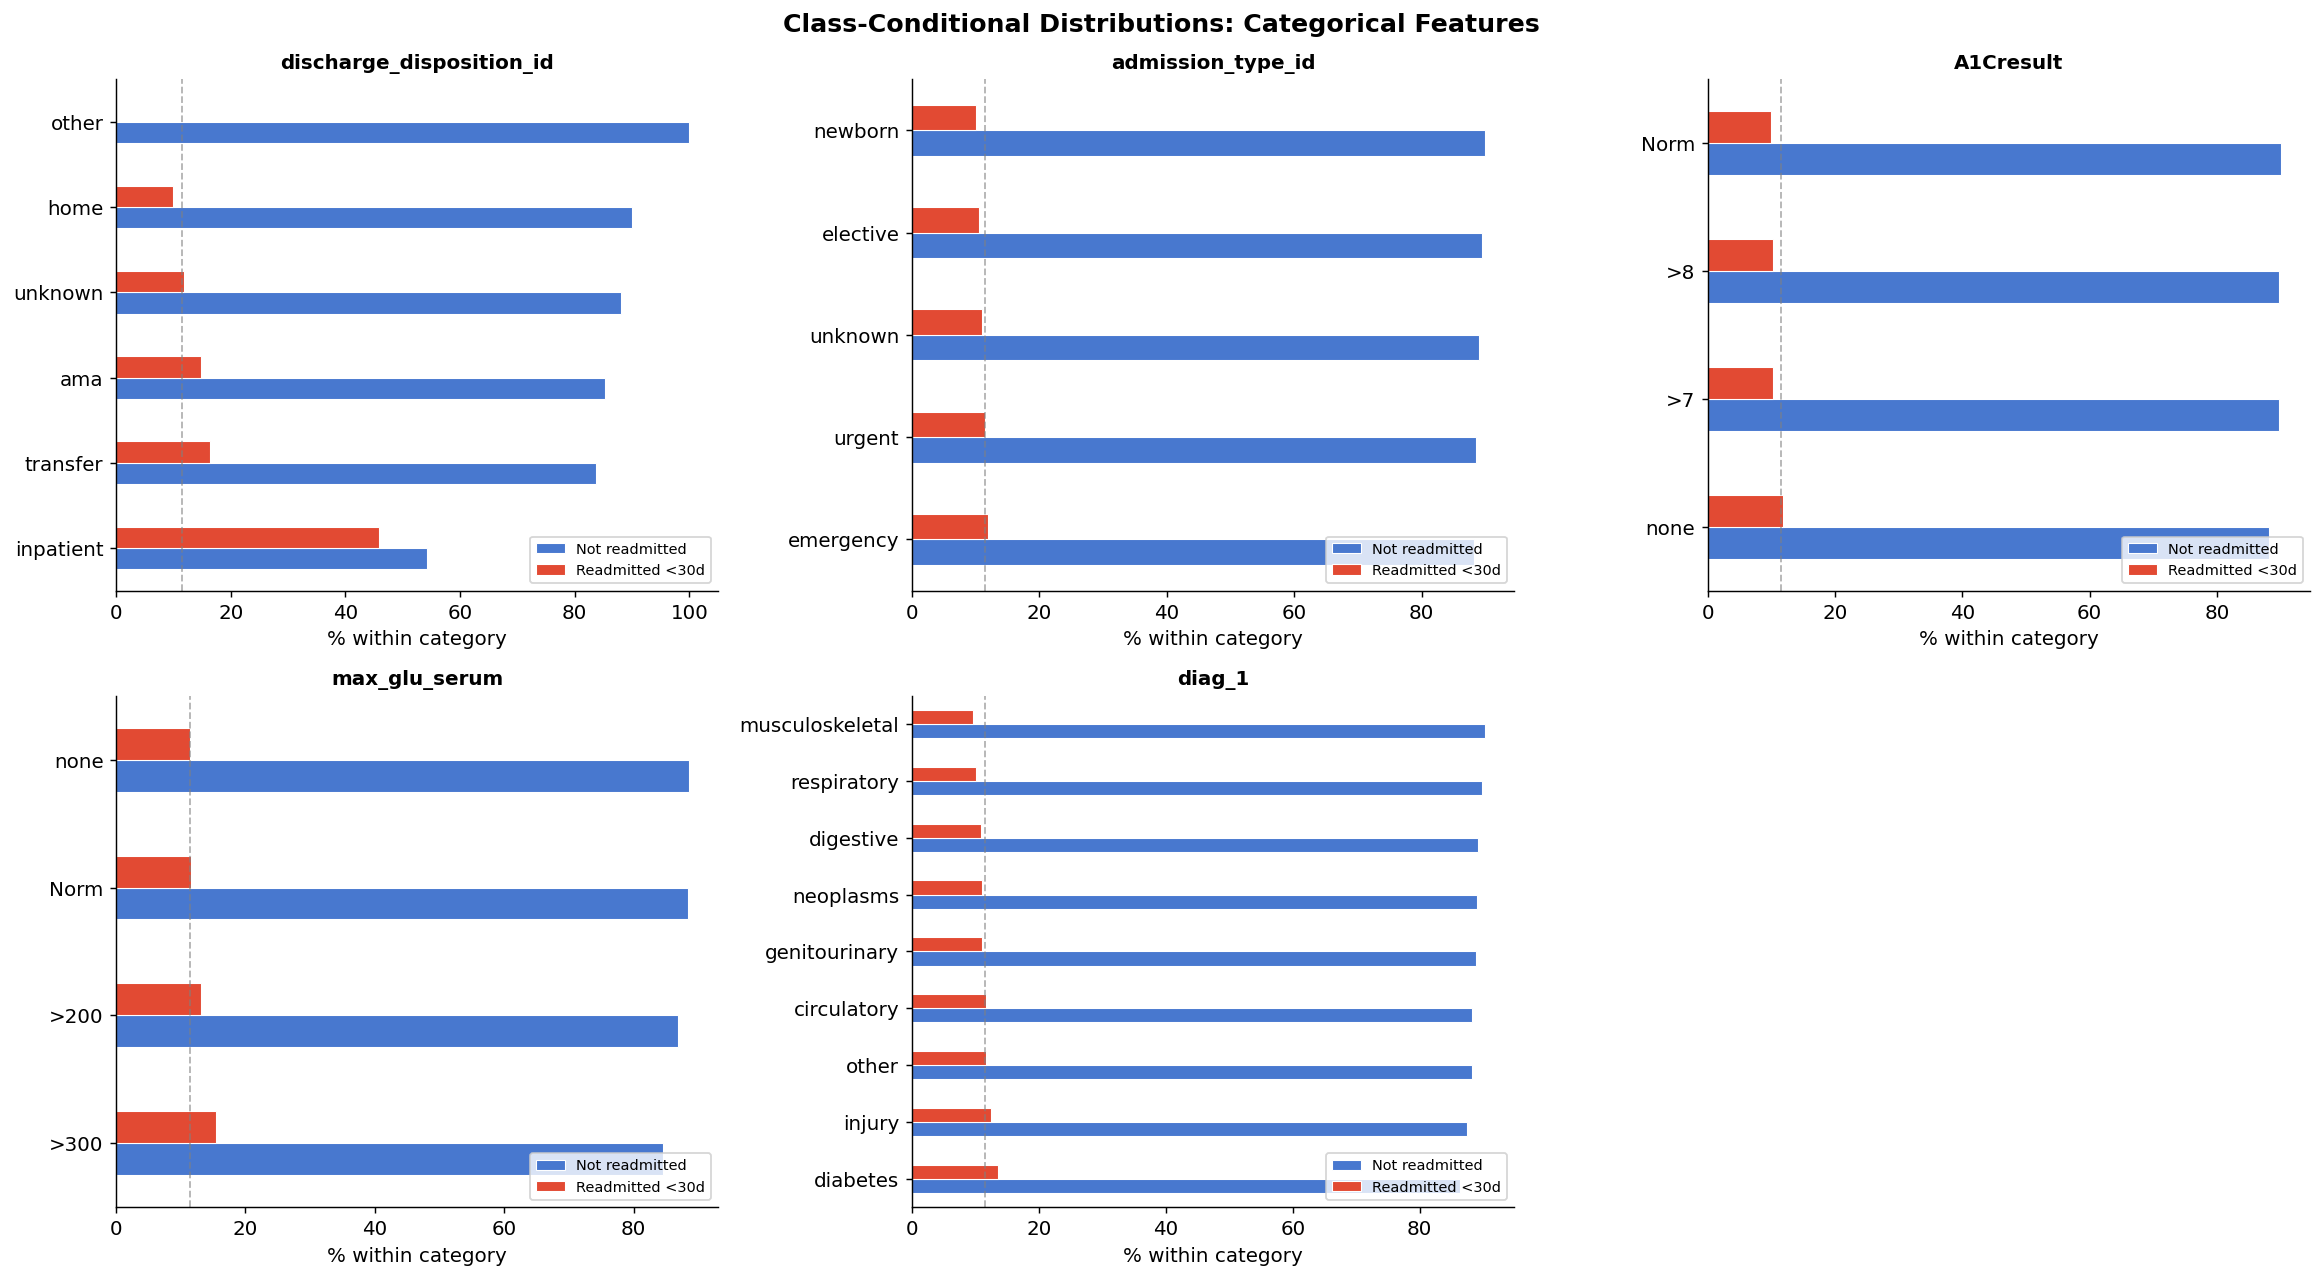

In [5]:
CAT_FEATURES = [
    'discharge_disposition_id', 'admission_type_id',
    'A1Cresult', 'max_glu_serum', 'diag_1'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Class-Conditional Distributions: Categorical Features', fontweight='bold', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(CAT_FEATURES):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df['readmitted_binary'], normalize='index') * 100
    ct.columns = ['Not readmitted', 'Readmitted <30d']
    ct.sort_values('Readmitted <30d', ascending=False, inplace=True)

    ct.plot(kind='barh', ax=ax, color=list(PALETTE.values()),
            edgecolor='white', linewidth=0.6)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('% within category')
    ax.set_ylabel('')
    ax.legend(fontsize=8, loc='lower right')
    ax.axvline(x=y.mean() * 100, color='gray', linestyle='--', alpha=0.6, linewidth=1)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('figures/03_class_conditional_categorical.png', bbox_inches='tight')
plt.show()

## 5. Engineered Features: Clinical Validation

These three features — `service_utilization`, `medication_count`, and
`HbA1c_diabetes_interaction` — were added based on the literature.
This section validates that they actually carry the expected signal.

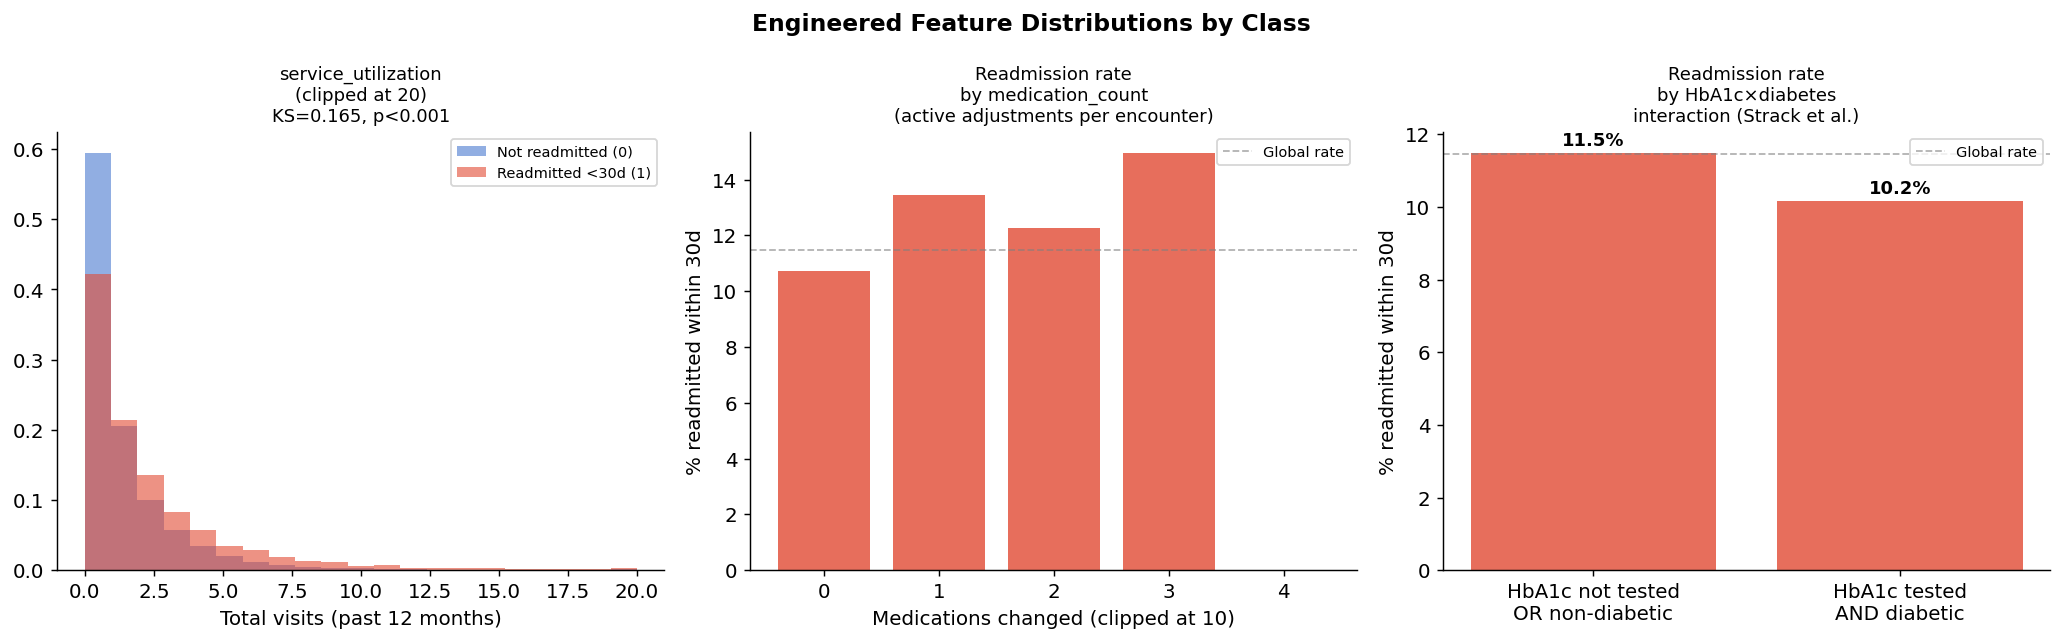

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Engineered Feature Distributions by Class', fontweight='bold', fontsize=13)

# ── service_utilization ───────────────────────────────────────────────────────
ax = axes[0]
for label, color in zip([0, 1], list(PALETTE.values())):
    vals = df[df['readmitted_binary'] == label]['service_utilization']
    ax.hist(vals.clip(upper=20), bins=21, alpha=0.6, color=color,
            density=True, label=list(PALETTE.keys())[label])
ks_s, ks_p = ks_2samp(
    df[df['readmitted_binary']==0]['service_utilization'],
    df[df['readmitted_binary']==1]['service_utilization']
)
ax.set_title(f'service_utilization\n(clipped at 20)\nKS={ks_s:.3f}, p<0.001', fontsize=10)
ax.set_xlabel('Total visits (past 12 months)')
ax.legend(fontsize=8)

# ── medication_count ──────────────────────────────────────────────────────────
ax = axes[1]
mc_cross = pd.crosstab(
    df['medication_count'].clip(upper=10),
    df['readmitted_binary'],
    normalize='index'
) * 100
if 1 in mc_cross.columns:
    ax.bar(mc_cross.index, mc_cross[1], color=list(PALETTE.values())[1], alpha=0.8)
ax.axhline(y.mean()*100, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='Global rate')
ax.set_title('Readmission rate\nby medication_count\n(active adjustments per encounter)', fontsize=10)
ax.set_xlabel('Medications changed (clipped at 10)')
ax.set_ylabel('% readmitted within 30d')
ax.legend(fontsize=8)

# ── HbA1c_diabetes_interaction ────────────────────────────────────────────────
ax = axes[2]
hba1c_cross = pd.crosstab(
    df['HbA1c_diabetes_interaction'],
    df['readmitted_binary'],
    normalize='index'
) * 100
bar_labels = ['HbA1c not tested\nOR non-diabetic', 'HbA1c tested\nAND diabetic']
bars = ax.bar(
    bar_labels,
    hba1c_cross[1].values if 1 in hba1c_cross.columns else [0, 0],
    color=list(PALETTE.values())[1], alpha=0.8
)
ax.axhline(y.mean()*100, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='Global rate')
for bar, val in zip(bars, hba1c_cross[1].values if 1 in hba1c_cross.columns else []):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Readmission rate\nby HbA1c×diabetes\ninteraction (Strack et al.)', fontsize=10)
ax.set_ylabel('% readmitted within 30d')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/04_engineered_features.png', bbox_inches='tight')
plt.show()

## 6. Feature Correlation and Redundancy

Before studying heterogeneity, it is useful to know which continuous features move together.
Highly correlated features imply that client distribution shift in one will manifest in
correlated shifts in others — the effective dimensionality of the heterogeneity is lower
than the raw feature count.

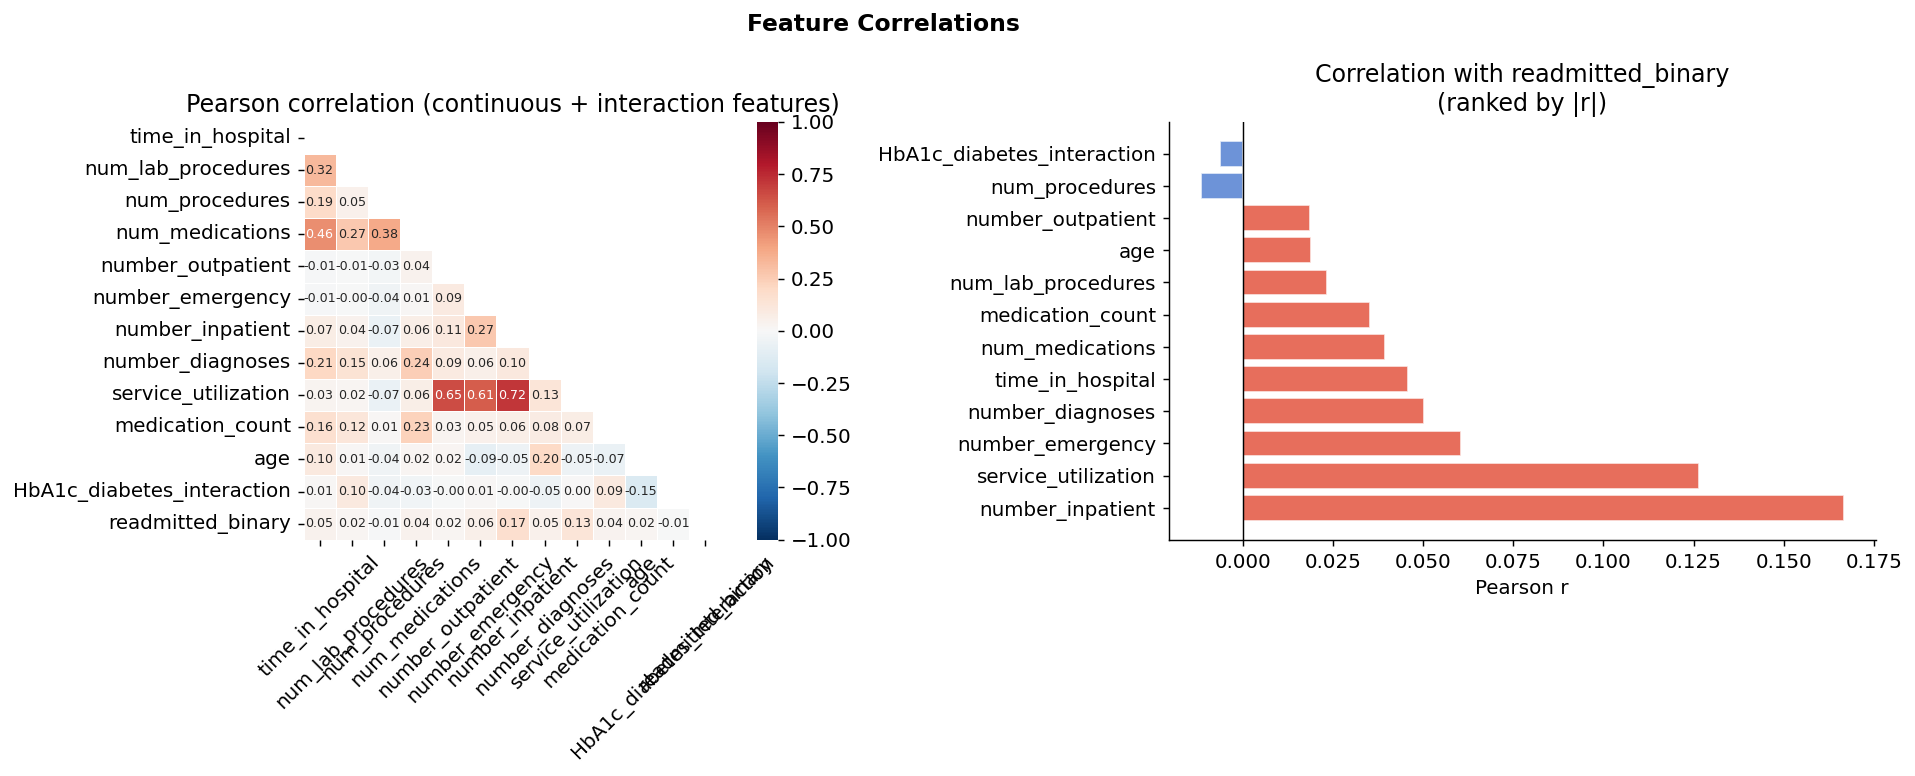

In [7]:
cont_cols = CONTINUOUS_FEATURES + ['HbA1c_diabetes_interaction']
corr = df[cont_cols + ['readmitted_binary']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Correlations', fontweight='bold', fontsize=13)

# Full correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=axes[0], mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, square=True
)
axes[0].set_title('Pearson correlation (continuous + interaction features)')
axes[0].tick_params(axis='x', rotation=45)

# Point-biserial correlation with target (discriminative power ranking)
target_corr = corr['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)
colors_bar = [list(PALETTE.values())[1] if v > 0 else list(PALETTE.values())[0]
              for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with readmitted_binary\n(ranked by |r|)')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('figures/05_feature_correlations.png', bbox_inches='tight')
plt.show()

## 7. Dirichlet Partitioning: How Heterogeneity Distorts Client Distributions

This is the core of the experimental design. For each α value we generate one
partitioning of patients into 5 clients and visualize:
- The positive rate per client (how skewed the label distributions are).
- The Wasserstein distance of each client's key feature distributions from the global.

The Wasserstein distance $W_1$ is the natural measure of distribution divergence here
because it corresponds directly to the $d_{\mathcal{H}\Delta\mathcal{H}}$ term in
Theorem 1 of the FedGen paper — larger $W_1$ predicts worse global model performance.

In [8]:
def dirichlet_partition(unique_patients, patient_labels_map, n_clients, alpha, rng, 
                         min_pos_rate=0.005, max_retries=300):
    """
    Partition patients into n_clients groups using a Dirichlet distribution over
    patient label (positive / negative) proportions.
    Returns a dict {client_id: [patient_ids]} or raises RuntimeError if
    no valid partition is found within max_retries.
    """
    pos_patients = [p for p in unique_patients if patient_labels_map.get(p, 0) == 1]
    neg_patients = [p for p in unique_patients if patient_labels_map.get(p, 0) == 0]

    for attempt in range(max_retries):
        proportions_pos = rng.dirichlet([alpha] * n_clients)
        proportions_neg = rng.dirichlet([alpha] * n_clients)

        rng.shuffle(pos_patients)
        rng.shuffle(neg_patients)

        splits_pos = np.split(pos_patients, (np.cumsum(proportions_pos)[:-1] * len(pos_patients)).astype(int))
        splits_neg = np.split(neg_patients, (np.cumsum(proportions_neg)[:-1] * len(neg_patients)).astype(int))

        partition = {k: list(splits_pos[k]) + list(splits_neg[k]) for k in range(n_clients)}

        # Validity check
        valid = True
        for k, pids in partition.items():
            if len(pids) < 100:
                valid = False; break
            pos_in_client = sum(patient_labels_map.get(p, 0) for p in pids)
            if pos_in_client / len(pids) < min_pos_rate:
                valid = False; break
        if valid:
            return partition
    raise RuntimeError(f'Could not find valid partition for α={alpha} after {max_retries} retries')


# Build patient → label map from the full dataset
df_full_raw = pd.read_csv(CSV_MAIN)
patient_labels_map = (
    df_full_raw.groupby('patient_nbr')['readmitted']
    .apply(lambda x: 1 if (x == '<30').any() else 0)
    .to_dict()
)
unique_patients = np.array(list(patient_labels_map.keys()))

print(f'Unique patients: {len(unique_patients):,}')
print(f'Positive patients (ever readmitted <30d): {sum(patient_labels_map.values()):,}')

Unique patients: 71,518
Positive patients (ever readmitted <30d): 8,834


In [9]:
# ── Generate partitions for each alpha ────────────────────────────────────────
partitions_by_alpha = {}
rng = np.random.default_rng(SEED)

for alpha in ALPHA_SWEEP:
    try:
        partition = dirichlet_partition(
            unique_patients, patient_labels_map, N_CLIENTS, alpha, rng
        )
        partitions_by_alpha[alpha] = partition
        sizes   = [len(v) for v in partition.values()]
        pos_rates = [
            sum(patient_labels_map.get(p, 0) for p in v) / len(v)
            for v in partition.values()
        ]
        print(f'α={alpha:.1f} → sizes: {[f"{s:,}" for s in sizes]} | pos rates: {[f"{r:.3f}" for r in pos_rates]}')
    except RuntimeError as e:
        print(f'α={alpha:.1f} → FAILED: {e}')

α=0.1 → sizes: ['513', '62,604', '278', '7,633', '490'] | pos rates: ['0.994', '0.012', '0.428', '0.909', '0.998']
α=0.5 → sizes: ['2,887', '14,062', '10,057', '14,605', '29,907'] | pos rates: ['0.964', '0.122', '0.182', '0.020', '0.074']
α=1.0 → sizes: ['32,017', '6,004', '10,097', '12,247', '11,153'] | pos rates: ['0.035', '0.644', '0.064', '0.036', '0.246']
α=5.0 → sizes: ['11,300', '17,128', '16,338', '12,244', '14,508'] | pos rates: ['0.115', '0.065', '0.091', '0.203', '0.169']


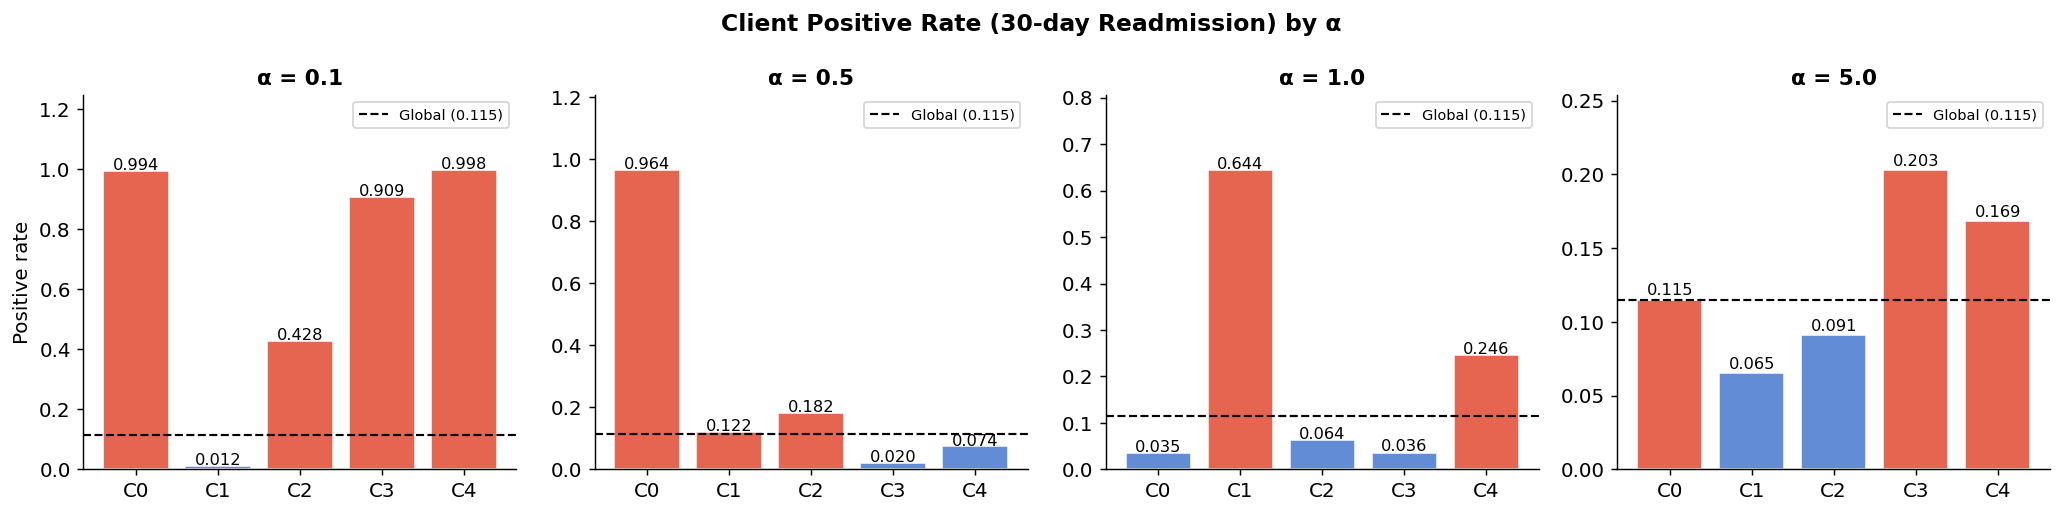

In [10]:
# ── Visualize positive rate distributions across alpha values ─────────────────
n_alphas = len(partitions_by_alpha)
fig, axes = plt.subplots(1, n_alphas, figsize=(4 * n_alphas, 4), sharey=False)
if n_alphas == 1:
    axes = [axes]
fig.suptitle('Client Positive Rate (30-day Readmission) by α', fontweight='bold', fontsize=13)

global_pos_rate = y.mean()

for ax, (alpha, partition) in zip(axes, partitions_by_alpha.items()):
    pos_rates = [
        sum(patient_labels_map.get(p, 0) for p in v) / len(v)
        for v in partition.values()
    ]
    bar_colors = [list(PALETTE.values())[1] if r > global_pos_rate else list(PALETTE.values())[0]
                  for r in pos_rates]
    bars = ax.bar([f'C{k}' for k in range(N_CLIENTS)], pos_rates,
                  color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(global_pos_rate, color='black', linestyle='--', linewidth=1.2,
               label=f'Global ({global_pos_rate:.3f})')
    ax.set_title(f'α = {alpha}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Positive rate' if ax == axes[0] else '')
    ax.set_ylim(0, max(pos_rates) * 1.25)
    ax.legend(fontsize=8)
    for bar, r in zip(bars, pos_rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{r:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/06_client_positive_rates.png', bbox_inches='tight')
plt.show()

## 8. Wasserstein Distance: Client vs. Global Distribution

For each (α, client, feature) triplet, we compute the 1-Wasserstein distance between
the client's feature distribution and the global distribution. This quantifies how
much the Dirichlet split distorts each feature's distribution, and for which features
the distortion is strongest.

This directly operationalizes the $d_{\mathcal{H}\Delta\mathcal{H}}$ term from
FedGen's Theorem 1: clients with high Wasserstein distances on discriminative features
are the ones that will benefit most from the generator's inductive bias.

In [11]:
WASS_FEATURES = [
    'time_in_hospital', 'number_inpatient', 'number_emergency',
    'service_utilization', 'medication_count', 'num_medications', 'age'
]

global_distributions = {feat: df[feat].values for feat in WASS_FEATURES}

wass_records = []

for alpha, partition in partitions_by_alpha.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        client_df = df[df['patient_nbr'].isin(pid_set)] if 'patient_nbr' in df.columns else df.iloc[:0]
        
        for feat in WASS_FEATURES:
            if feat in df.columns:
                client_vals = df.loc[df['patient_nbr'].isin(pid_set), feat].values if 'patient_nbr' in df.columns else np.array([])
                if len(client_vals) > 10:
                    w = wasserstein_distance(global_distributions[feat], client_vals)
                    wass_records.append({
                        'alpha': alpha, 'client': f'C{client_id}',
                        'feature': feat, 'wasserstein': w
                    })

wass_df = pd.DataFrame(wass_records)
print(wass_df.groupby(['alpha', 'feature'])['wasserstein'].mean().unstack('feature').round(4))

feature     age  medication_count  num_medications  number_emergency  \
alpha                                                                  
0.1      0.1105            0.0482           0.7713            0.1469   
0.5      0.0252            0.0184           0.2937            0.0781   
1.0      0.0337            0.0182           0.2967            0.0678   
5.0      0.0218            0.0054           0.1213            0.0295   

feature  number_inpatient  service_utilization  time_in_hospital  
alpha                                                             
0.1                0.7260               0.9672            0.3364  
0.5                0.2818               0.3970            0.1421  
1.0                0.3033               0.4153            0.1284  
5.0                0.1003               0.1412            0.0362  


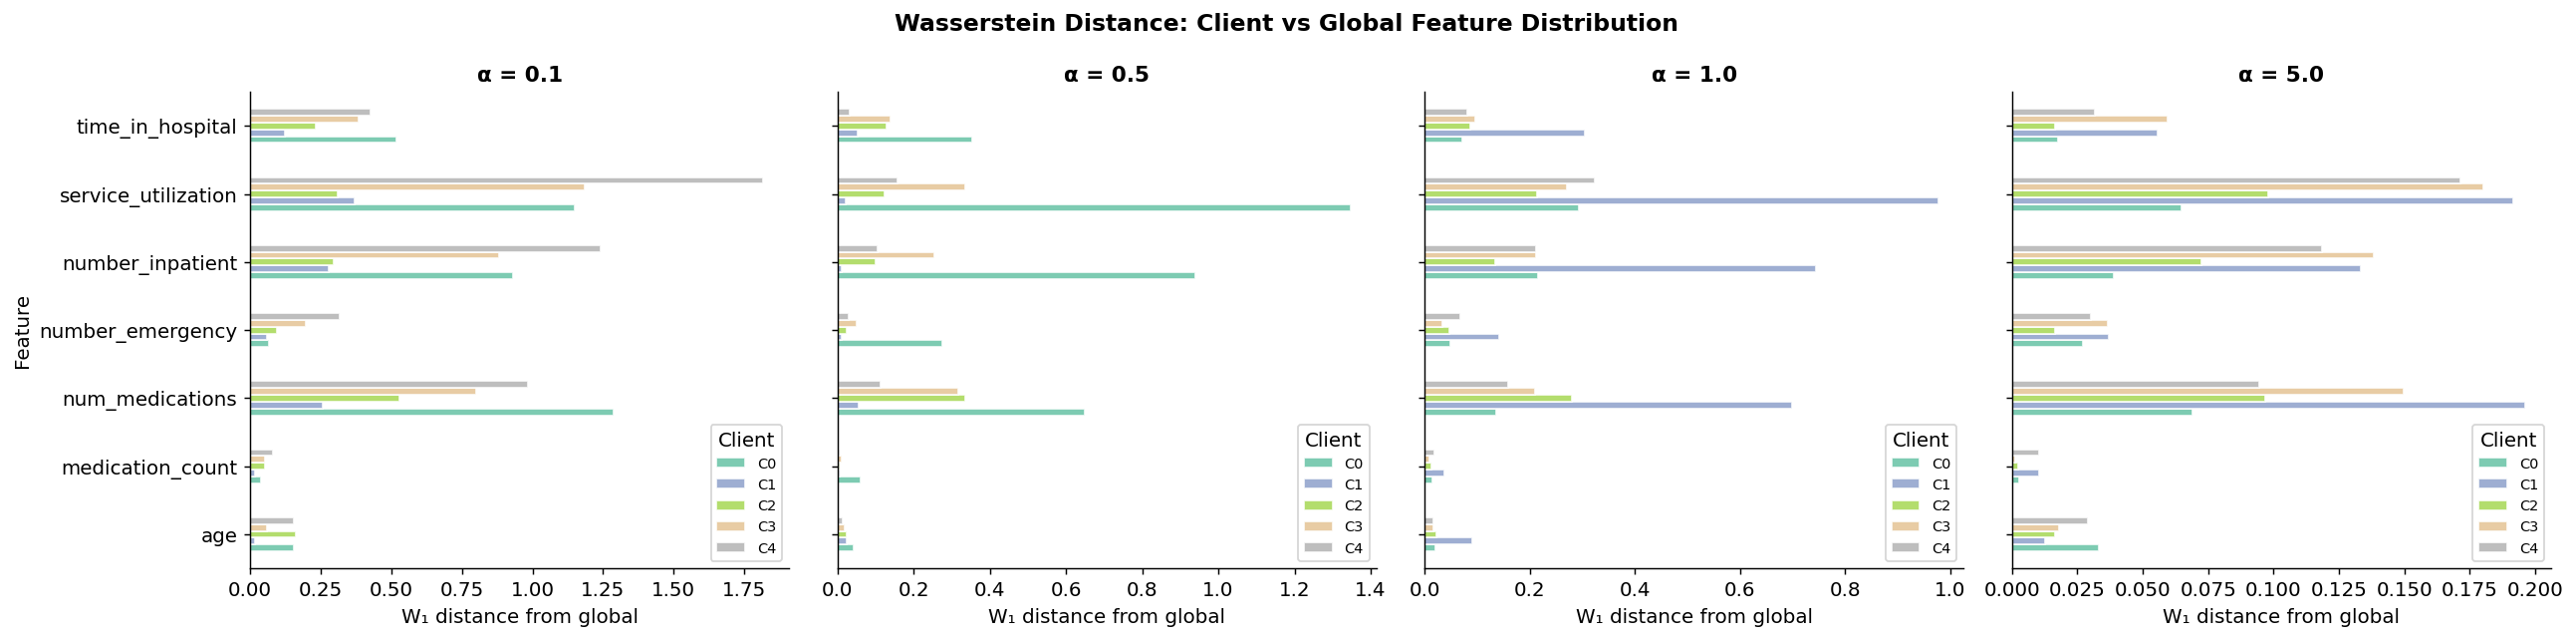

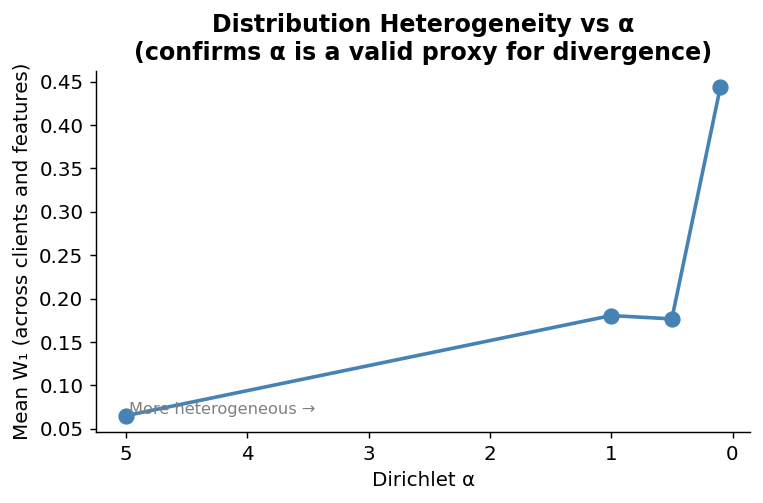

In [12]:
if not wass_df.empty:
    fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 5), sharey=True)
    if len(ALPHA_SWEEP) == 1:
        axes = [axes]
    fig.suptitle('Wasserstein Distance: Client vs Global Feature Distribution',
                 fontweight='bold', fontsize=13)

    for ax, alpha in zip(axes, ALPHA_SWEEP):
        sub = wass_df[wass_df['alpha'] == alpha]
        if sub.empty:
            ax.set_visible(False); continue
        pivot = sub.pivot(index='feature', columns='client', values='wasserstein')
        pivot.plot(kind='barh', ax=ax, colormap='Set2', alpha=0.85, edgecolor='white')
        ax.set_title(f'α = {alpha}', fontsize=12, fontweight='bold')
        ax.set_xlabel('W₁ distance from global')
        ax.set_ylabel('Feature' if ax == axes[0] else '')
        ax.legend(title='Client', fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig('figures/07_wasserstein_distances.png', bbox_inches='tight')
    plt.show()

    # Mean W1 per alpha — summary of how heterogeneity scales with α
    mean_wass = wass_df.groupby('alpha')['wasserstein'].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(mean_wass.index, mean_wass.values, 'o-', color='steelblue',
            linewidth=2, markersize=8)
    ax.set_xlabel('Dirichlet α')
    ax.set_ylabel('Mean W₁ (across clients and features)')
    ax.set_title('Distribution Heterogeneity vs α\n(confirms α is a valid proxy for divergence)',
                 fontweight='bold')
    ax.invert_xaxis()
    ax.annotate('More heterogeneous →', xy=(0.05, 0.05), xycoords='axes fraction',
                fontsize=9, color='gray')
    plt.tight_layout()
    plt.savefig('figures/08_mean_wasserstein_vs_alpha.png', bbox_inches='tight')
    plt.show()

## 9. Latent Space Analysis: Where the Generator Actually Operates

With `hidden_dim = 512`, your MLP architecture is:

```
Feature extractor θ^f:  99 → 512 → 256 → 128   (LayerNorm + ReLU + Dropout)
Predictor head θ^p:      128 → 2
```

The FedGen generator operates in **Z = ℝ¹²⁸** (the 128-dimensional penultimate layer).
Here we load the saved centralized MLP and inspect the class-conditional geometry of
the latent space — this is what the generator is trying to approximate.

If the two classes are well-separated in latent space, the generator has a clearly
defined target distribution. If they overlap significantly, the generator's task is
harder and the inductive bias is weaker.

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4), nn.ReLU(), nn.Dropout(dropout),
        )
        self.predictor = nn.Linear(hidden_dim // 4, output_dim)

    def forward(self, x):
        return self.predictor(self.feature_extractor(x))

    def encode(self, x):
        return self.feature_extractor(x)


# ── Load centralized checkpoint ───────────────────────────────────────────────
# Adjust path to your saved model
CKPT_PATH = '../Centralized/models/mlp_centralized.pt'

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    hidden_dim = ckpt.get('hidden_dim', 256)
    dropout    = ckpt.get('dropout',    0.3)
    scaler     = ckpt.get('scaler',     StandardScaler())

    model = MLP(input_dim=X.shape[1], hidden_dim=hidden_dim, dropout=dropout).to(device)

    # Remap state_dict keys: original model uses 'net.*', new uses 'feature_extractor.*' / 'predictor.*'
    orig_sd = ckpt['model_state_dict']
    new_sd  = {}
    fe_layers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  # indices in original net.Sequential
    # Map net.0..net.11 → feature_extractor, net.12 → predictor
    for k, v in orig_sd.items():
        if k.startswith('net.'):
            idx = int(k.split('.')[1])
            rest = '.'.join(k.split('.')[2:])
            if idx < 12:  # feature extractor layers
                new_sd[f'feature_extractor.{idx}.{rest}'] = v
            else:
                new_sd[f'predictor.{rest}'] = v
        else:
            new_sd[k] = v

    model.load_state_dict(new_sd, strict=False)
    model.eval()

    # ── Extract latent representations ────────────────────────────────────────
    X_scaled = scaler.transform(X) if hasattr(scaler, 'mean_') else X
    X_t = torch.tensor(X_scaled, dtype=torch.float32)

    latent_vecs = []
    with torch.no_grad():
        loader = DataLoader(TensorDataset(X_t), batch_size=2048)
        for (xb,) in loader:
            latent_vecs.append(model.encode(xb.to(device)).cpu().numpy())
    Z = np.concatenate(latent_vecs, axis=0)

    print(f'Latent space shape: {Z.shape}  (n_samples × latent_dim)')
    LATENT_LOADED = True
else:
    print(f'Checkpoint not found at {CKPT_PATH}.')
    print('Skipping latent space analysis. Run this after training the centralized model.')
    LATENT_LOADED = False

Latent space shape: (97825, 128)  (n_samples × latent_dim)


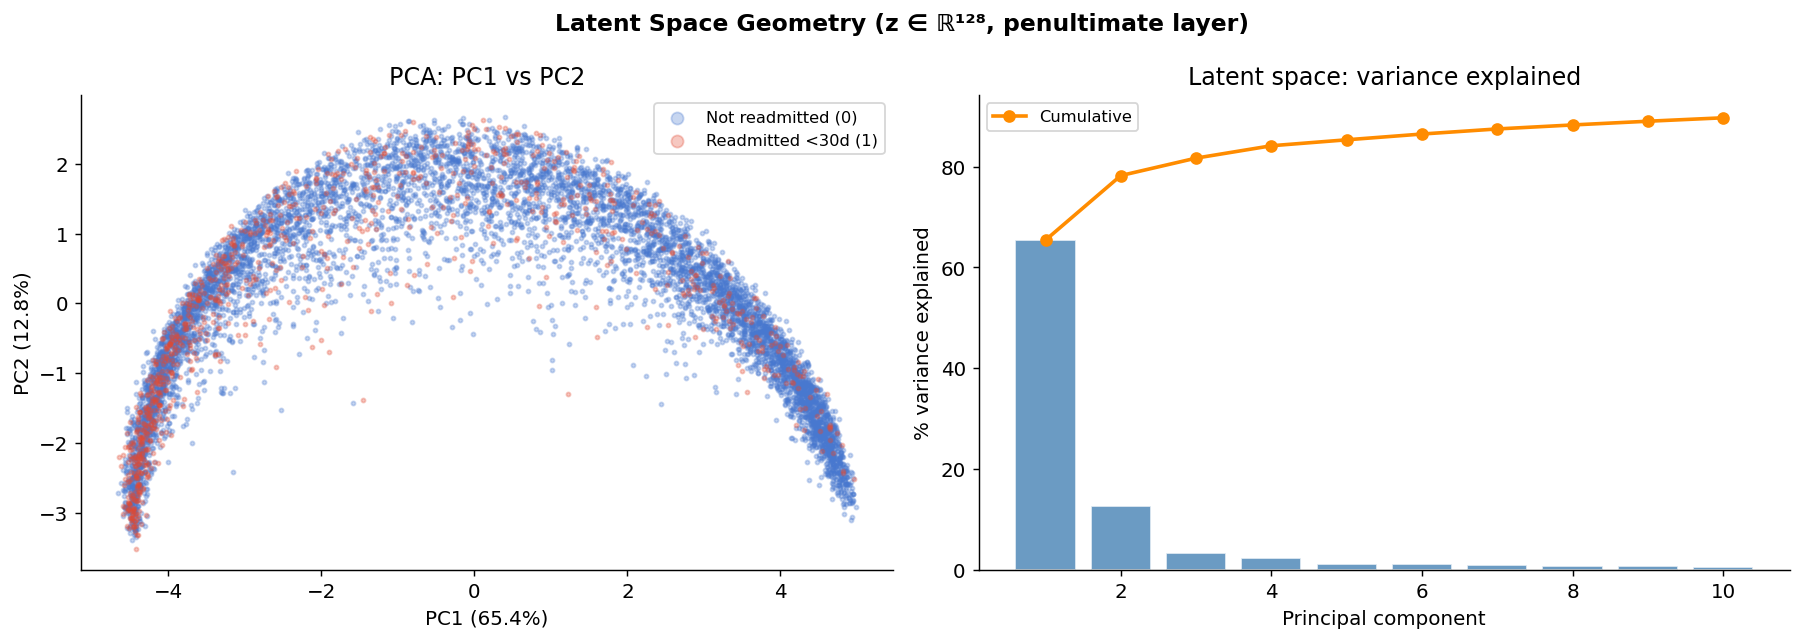


Latent space class-conditional statistics:
  Class 0 — mean norm: 5.784 | mean intra-class dist (sample): 3.407
  Class 1 — mean norm: 5.892 | mean intra-class dist (sample): 3.617
  Inter-class centroid distance: 2.031
  Latent dimension: 128

  → These are the prototype centroids z̄_y that a constrained generator should stay near.


In [14]:
if LATENT_LOADED:
    # ── PCA of latent space, colored by class ─────────────────────────────────
    pca = PCA(n_components=10)
    Z_pca = pca.fit_transform(Z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Latent Space Geometry (z ∈ ℝ¹²⁸, penultimate layer)',
                 fontweight='bold', fontsize=13)

    # Subsample for visualization
    idx_sub = np.random.default_rng(SEED).choice(len(Z), size=min(8000, len(Z)), replace=False)
    Z_sub   = Z_pca[idx_sub]
    y_sub   = y[idx_sub]

    # PC1 vs PC2
    for label, (name, color) in zip([0, 1], PALETTE.items()):
        mask = y_sub == label
        axes[0].scatter(Z_sub[mask, 0], Z_sub[mask, 1],
                        c=color, alpha=0.3, s=5, label=name, rasterized=True)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title('PCA: PC1 vs PC2')
    axes[0].legend(markerscale=3, fontsize=9)

    # Explained variance
    axes[1].bar(range(1, 11), pca.explained_variance_ratio_ * 100,
                color='steelblue', alpha=0.8, edgecolor='white')
    axes[1].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100,
                 'o-', color='darkorange', linewidth=2, markersize=6, label='Cumulative')
    axes[1].set_xlabel('Principal component')
    axes[1].set_ylabel('% variance explained')
    axes[1].set_title('Latent space: variance explained')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('figures/09_latent_space_pca.png', bbox_inches='tight')
    plt.show()

    # ── Per-class statistics in latent space ──────────────────────────────────
    Z0 = Z[y == 0]
    Z1 = Z[y == 1]

    print('\nLatent space class-conditional statistics:')
    print(f'  Class 0 — mean norm: {np.linalg.norm(Z0.mean(0)):.3f} | '
          f'mean intra-class dist (sample): {np.mean(np.linalg.norm(Z0[:500] - Z0[:500].mean(0), axis=1)):.3f}')
    print(f'  Class 1 — mean norm: {np.linalg.norm(Z1.mean(0)):.3f} | '
          f'mean intra-class dist (sample): {np.mean(np.linalg.norm(Z1[:500] - Z1[:500].mean(0), axis=1)):.3f}')
    inter_dist = np.linalg.norm(Z0.mean(0) - Z1.mean(0))
    print(f'  Inter-class centroid distance: {inter_dist:.3f}')
    print(f'  Latent dimension: {Z.shape[1]}')
    print(f'\n  → These are the prototype centroids z̄_y that a constrained generator should stay near.')

## 10. Generator Constraint: Prototype Regularization

Based on the latent space analysis above, we define the per-class centroids $\bar{z}_y$
that can serve as the anchor for prototype regularization.

The modified generator loss with constraint is:

$$J(w) := \underbrace{\mathbb{E}_{y,z}\left[\ell\left(\sigma\left(\frac{1}{K}\sum_k g(z;\theta^p_k)\right), y\right)\right]}_{\text{ensemble classification loss}} + \underbrace{\lambda \cdot \mathbb{E}_{y, z\sim G_w(\cdot|y)} \left[ \|z - \bar{z}_y\|^2 \right]}_{\text{prototype regularization}}$$

This ensures generated representations stay near the latent region occupied by real
patients of each class. The hyperparameter $\lambda$ controls the trade-off between
ensemble consensus (original objective) and distributional fidelity (constraint).

Prototype centroids (z̄_y) computed:
  z̄_{y=0}: shape=(128,), norm=5.784, mean std=0.288
  z̄_{y=1}: shape=(128,), norm=5.892, mean std=0.271

Mean intra-class variance: class0=0.123, class1=0.109
Suggested λ starting point: ~0.1 (ablate over [0.0, 0.01, 0.1, 1.0])


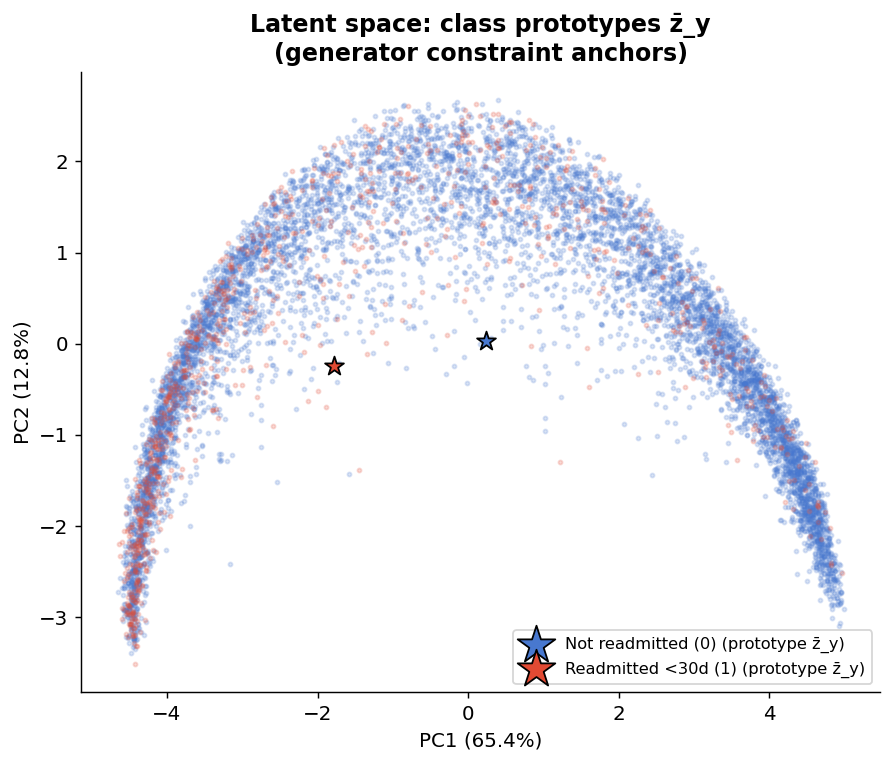


Prototypes saved to prototypes_class0.npy / prototypes_class1.npy


In [15]:
if LATENT_LOADED:
    # Compute and save per-class prototypes
    prototypes = {
        0: Z[y == 0].mean(axis=0),  # z̄_{y=0}
        1: Z[y == 1].mean(axis=0),  # z̄_{y=1}
    }
    prototype_stds = {
        0: Z[y == 0].std(axis=0),
        1: Z[y == 1].std(axis=0),
    }

    print('Prototype centroids (z̄_y) computed:')
    for cls in [0, 1]:
        print(f'  z̄_{{y={cls}}}: shape={prototypes[cls].shape}, '
              f'norm={np.linalg.norm(prototypes[cls]):.3f}, '
              f'mean std={prototype_stds[cls].mean():.3f}')

    # Suggested λ: a fraction of the typical intra-class variance
    # so the constraint is soft but meaningful
    intra_var_0 = np.mean(np.var(Z[y == 0], axis=0))
    intra_var_1 = np.mean(np.var(Z[y == 1], axis=0))
    suggested_lambda_scale = 0.1  # 10% of intra-class variance
    print(f'\nMean intra-class variance: class0={intra_var_0:.3f}, class1={intra_var_1:.3f}')
    print(f'Suggested λ starting point: ~{suggested_lambda_scale} '
          f'(ablate over [0.0, 0.01, 0.1, 1.0])')

    # Visualize prototype + 1-std ellipse in PCA space
    fig, ax = plt.subplots(figsize=(7, 6))
    for label, (name, color) in zip([0, 1], PALETTE.items()):
        mask = y_sub == label
        ax.scatter(Z_sub[mask, 0], Z_sub[mask, 1],
                   c=color, alpha=0.2, s=5, rasterized=True)
        # Project prototype into PCA space
        proto_pca = pca.transform(prototypes[label].reshape(1, -1))[0]
        ax.scatter(*proto_pca[:2], c=color, s=120, marker='*',
                   edgecolors='black', linewidth=1, zorder=5,
                   label=f'{name} (prototype z̄_y)')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('Latent space: class prototypes z̄_y\n'
                 '(generator constraint anchors)', fontweight='bold')
    ax.legend(markerscale=2, fontsize=9)
    plt.tight_layout()
    plt.savefig('figures/10_latent_prototypes.png', bbox_inches='tight')
    plt.show()

    np.save('prototypes_class0.npy', prototypes[0])
    np.save('prototypes_class1.npy', prototypes[1])
    print('\nPrototypes saved to prototypes_class0.npy / prototypes_class1.npy')
else:
    print('Latent analysis skipped — train centralized model first.')

## 11. Summary

This section prints a structured summary of the key findings
relevant to the thesis experimental design.

In [16]:
print('=' * 65)
print('  DISTRIBUTION ANALYSIS SUMMARY')
print('=' * 65)

print(f'\n[DATASET]')
print(f'  Samples:        {len(y):,}')
print(f'  Features:       {X.shape[1]}')
print(f'  Positive rate:  {y.mean()*100:.2f}%  (7.73:1 imbalance)')

print(f'\n[MODEL ARCHITECTURE → LATENT SPACE]')
print(f'  MLP: 99 → 512 → 256 → 128 → 2')
print(f'  Feature extractor θ^f: 99 → 512 → 256 → 128')
print(f'  Predictor head θ^p: 128 → 2')
print(f'  FedGen generator Z dim: 128')
print(f'  Compression ratio: 99 → 128  (expansion, not compression!)')
print(f'  → Generator is NOT lightweight in the same sense as image FedGen.')

print(f'\n[MOST DISCRIMINATIVE FEATURES (KS statistic)]')
for _, row in ks_df.head(5).iterrows():
    print(f'  {row["Feature"]:<25} KS={row["KS statistic"]:.3f}  {row["Significant"]}')

if not wass_df.empty:
    print(f'\n[HETEROGENEITY SCALING WITH α (mean W₁)]')
    for alpha, w in mean_wass.items():
        bar = '█' * int(w * 30)
        print(f'  α={alpha:<5} {bar} {w:.4f}')

print(f'\n[FEDGEN GENERATOR CONSTRAINT RECOMMENDATION]')
print(f'  Approach: Prototype regularization')
print(f'  Loss term: λ · E[‖z − z̄_y‖²]  where z̄_y is the class centroid in Z')
print(f'  Suggested λ ablation: [0.0, 0.01, 0.1, 1.0]')
print(f'  Prototypes saved: prototypes_class0.npy / prototypes_class1.npy')

print(f'\n[THESIS EXPERIMENT DESIGN]')
print(f'  α sweep: {ALPHA_SWEEP}')
print(f'  N clients: {N_CLIENTS}')
print(f'  Metrics: global AUC, per-client AUC (equity), cumulative MB to convergence')
print(f'  Models: FedAvg, FedGen (unconstrained), FedGen (prototype-constrained)')
print('=' * 65)

  DISTRIBUTION ANALYSIS SUMMARY

[DATASET]
  Samples:        97,825
  Features:       99
  Positive rate:  11.46%  (7.73:1 imbalance)

[MODEL ARCHITECTURE → LATENT SPACE]
  MLP: 99 → 512 → 256 → 128 → 2
  Feature extractor θ^f: 99 → 512 → 256 → 128
  Predictor head θ^p: 128 → 2
  FedGen generator Z dim: 128
  Compression ratio: 99 → 128  (expansion, not compression!)
  → Generator is NOT lightweight in the same sense as image FedGen.

[MOST DISCRIMINATIVE FEATURES (KS statistic)]
  number_inpatient          KS=0.183  ***
  service_utilization       KS=0.165  ***
  time_in_hospital          KS=0.071  ***
  number_diagnoses          KS=0.069  ***
  num_medications           KS=0.064  ***

[HETEROGENEITY SCALING WITH α (mean W₁)]
  α=0.1   █████████████ 0.4438
  α=0.5   █████ 0.1766
  α=1.0   █████ 0.1805
  α=5.0   █ 0.0651

[FEDGEN GENERATOR CONSTRAINT RECOMMENDATION]
  Approach: Prototype regularization
  Loss term: λ · E[‖z − z̄_y‖²]  where z̄_y is the class centroid in Z
  Suggested λ